In [ ]:
from google.colab import files
uploaded = files.upload()
data_folder = uploaded

Saving Adult_Data.csv to Adult_Data.csv


In [ ]:
!pip install dowhy matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


#Define column names matching the dataset
csv_columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

#Load csv file w column nmes defined
data = pd.read_csv('Adult_Data.csv', names=csv_columns)

#Remove whitspace from columns, kept giving errors
for col in data.select_dtypes(include='object').columns:
  data[col] = data[col].str.strip()

# >50k is now 1 , <50k is 0 , binary encoding
data['income'] = (data['income'] == '>50K').astype(int)

# Categorical columns to encode (exclude numeric columns)
categorical_cols = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

#For storing results in order to plot
dp_results = {}
eq_odd_results = {}

#Encode the caategoricl columns according to previously defined labels
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data.drop(columns=['income'])
y = data['income']

# Stratified spliting is used to preserve original clss distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

def demographic_parity(y_pred, sensitive_attr):
    groups = np.unique(sensitive_attr)
    positive_rates = {}
    for group in groups:
      positive_rate = np.mean(y_pred[sensitive_attr ==group])
      positive_rates[group] = positive_rate
    return positive_rates

def equalized_odds(y_true, y_pred, sensitive_attr):
    groups = np.unique(sensitive_attr)
    eq_odd_metrics = {}
    for group in groups:
      idx = (sensitive_attr == group)
      confusion_matr = confusion_matrix(y_true[idx], y_pred[idx], labels=[0,1])
      tn, fp, fn, tp = confusion_matr.ravel()
      tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
      fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
      eq_odd_metrics[group] = {'TPR': tpr, 'FPR': fpr}
    return eq_odd_metrics

# Compute and print fairness metrics for each sensitive attribute
for attr in categorical_cols:
  attr_values = X_test[attr].values
  dp = demographic_parity(y_pred, attr_values)
  eq_odd = equalized_odds(y_test.values, y_pred, attr_values)

  dp_results[attr] = dp
  eq_odd_results[attr] = eq_odd

  print(f"Fairness metrics for attribute: {attr}" )
  print("Demographic Parity: ")
  for group, rate in dp.items():
      print(f"Group {group}: {rate:.3f}")
  print("Equalized Odds : ")
  for group, metrics in eq_odd.items():
      print(f"Group {group}: TPR={metrics['TPR']:.3f}, FPR={metrics['FPR']:.3f}")
  print("\n")


Fairness metrics for attribute: workclass
Demographic Parity: 
Group 0: 0.152
Group 1: 0.295
Group 2: 0.195
Group 3: 0.000
Group 4: 0.103
Group 5: 0.294
Group 6: 0.123
Group 7: 0.107
Group 8: 0.000
Equalized Odds : 
Group 0: TPR=0.633, FPR=0.094
Group 1: TPR=0.445, FPR=0.200
Group 2: TPR=0.440, FPR=0.093
Group 3: TPR=0.000, FPR=0.000
Group 4: TPR=0.323, FPR=0.041
Group 5: TPR=0.464, FPR=0.083
Group 6: TPR=0.330, FPR=0.050
Group 7: TPR=0.327, FPR=0.028
Group 8: TPR=0.000, FPR=0.000


Fairness metrics for attribute: education
Demographic Parity: 
Group 0: 0.024
Group 1: 0.035
Group 2: 0.052
Group 3: 0.022
Group 4: 0.025
Group 5: 0.005
Group 6: 0.013
Group 7: 0.152
Group 8: 0.140
Group 9: 0.262
Group 10: 0.688
Group 11: 0.057
Group 12: 0.368
Group 13: 0.000
Group 14: 0.511
Group 15: 0.058
Equalized Odds : 
Group 0: TPR=0.167, FPR=0.015
Group 1: TPR=0.467, FPR=0.015
Group 2: TPR=0.375, FPR=0.028
Group 3: TPR=0.500, FPR=0.000
Group 4: TPR=0.250, FPR=0.013
Group 5: TPR=0.000, FPR=0.006
Group

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


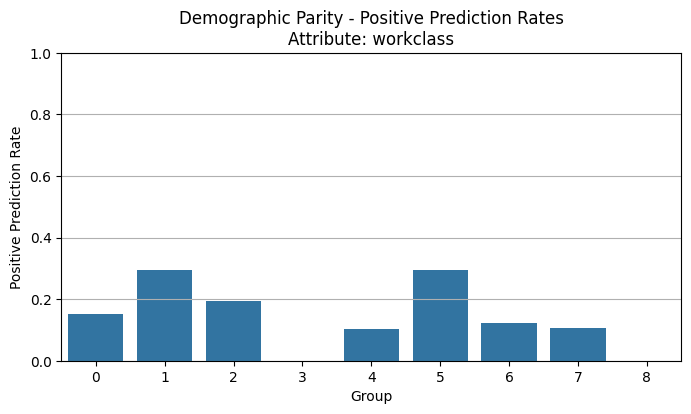

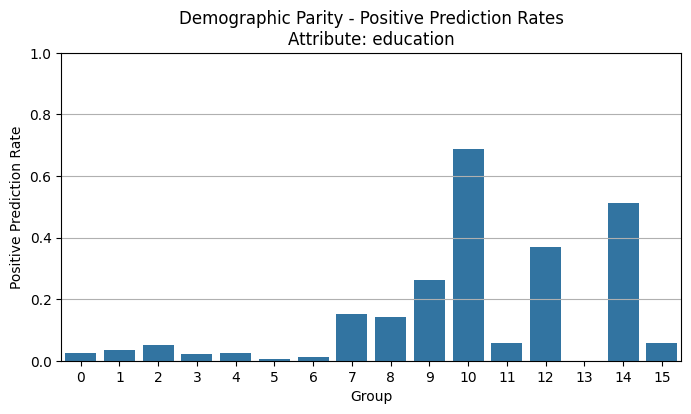

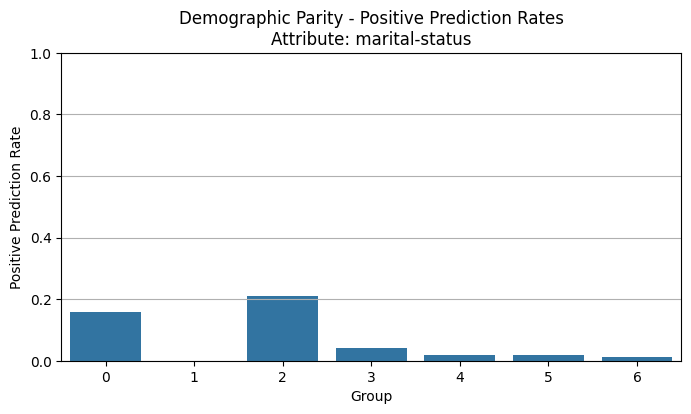

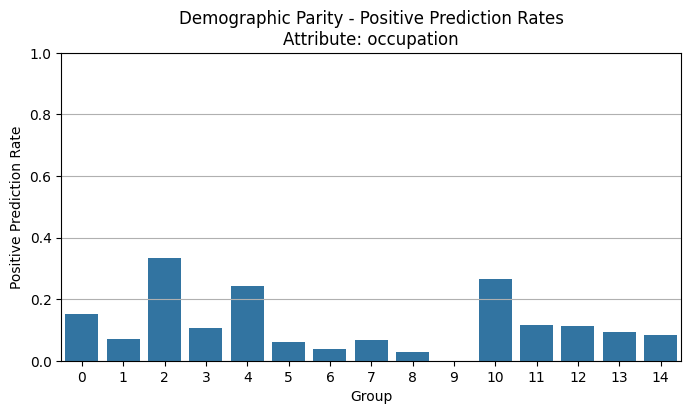

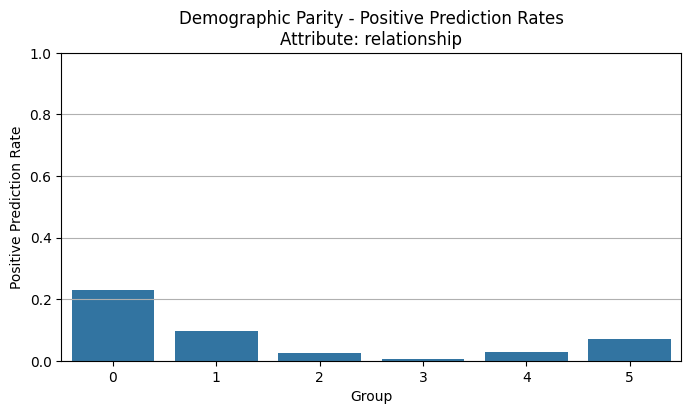

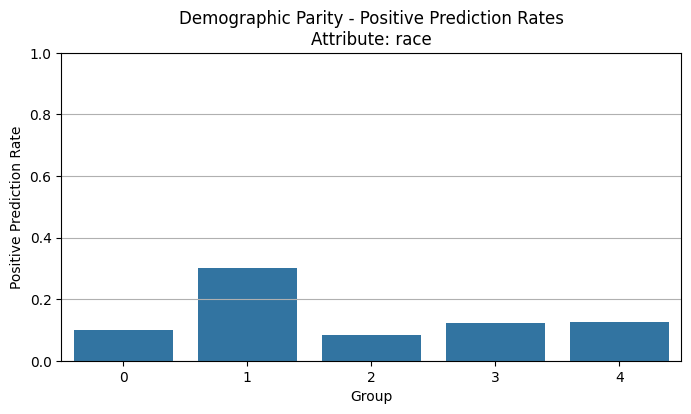

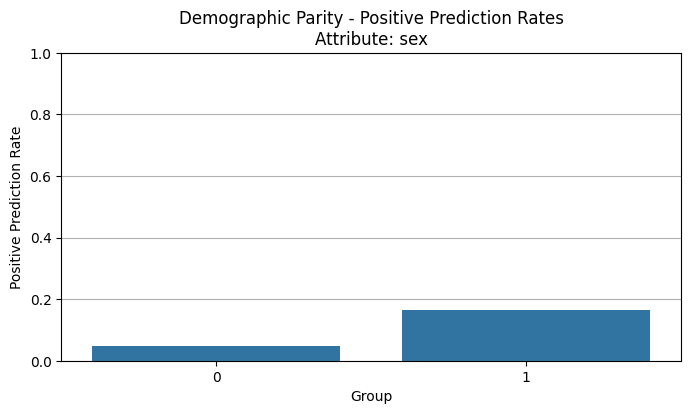

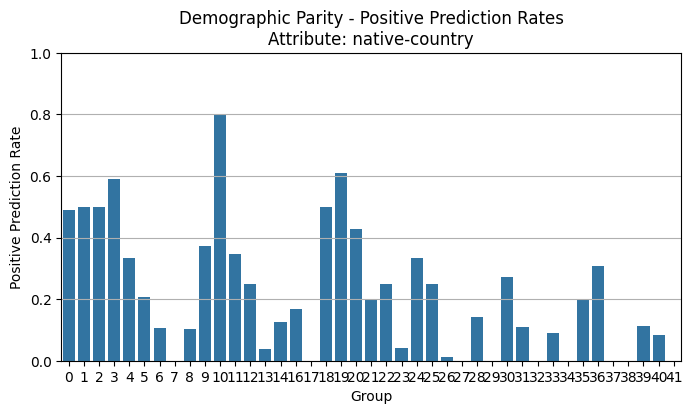

In [ ]:
for attr, rates in dp_results.items():
        groups = list(rates.keys())
        values = list(rates.values())

        plt.figure(figsize=(8,4))
        sns.barplot(x=groups, y=values)
        plt.title(f"Demographic Parity - Positive Prediction Rates\nAttribute: {attr}")
        plt.xlabel("Group")
        plt.ylabel("Positive Prediction Rate")
        plt.ylim(0, 1)
        plt.grid(axis='y')
        plt.show()

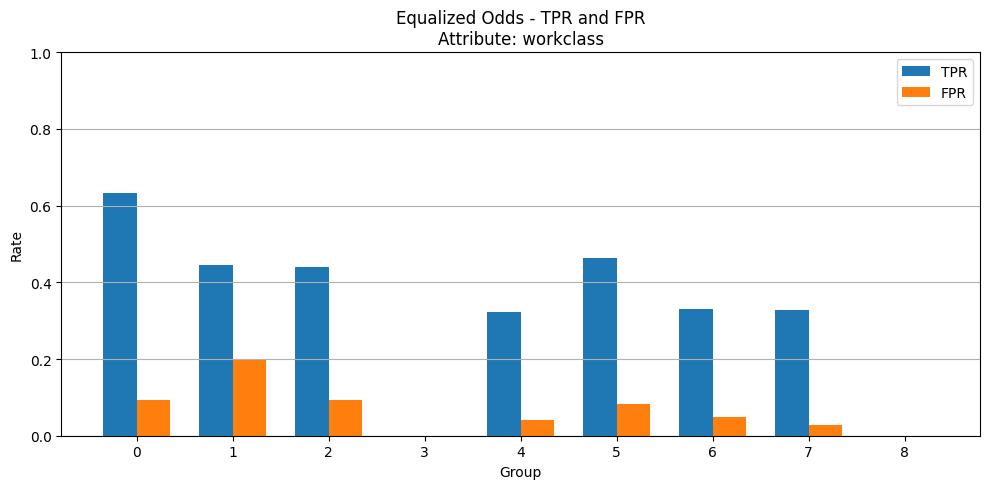

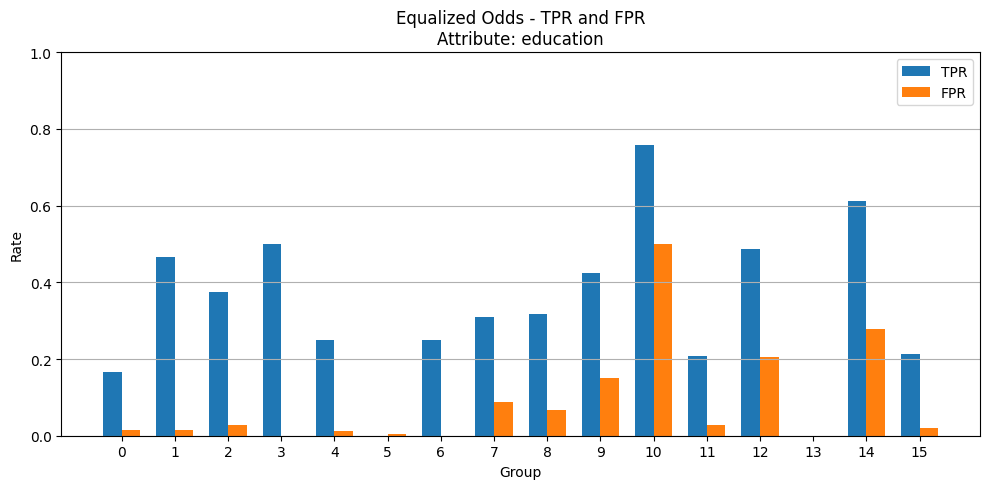

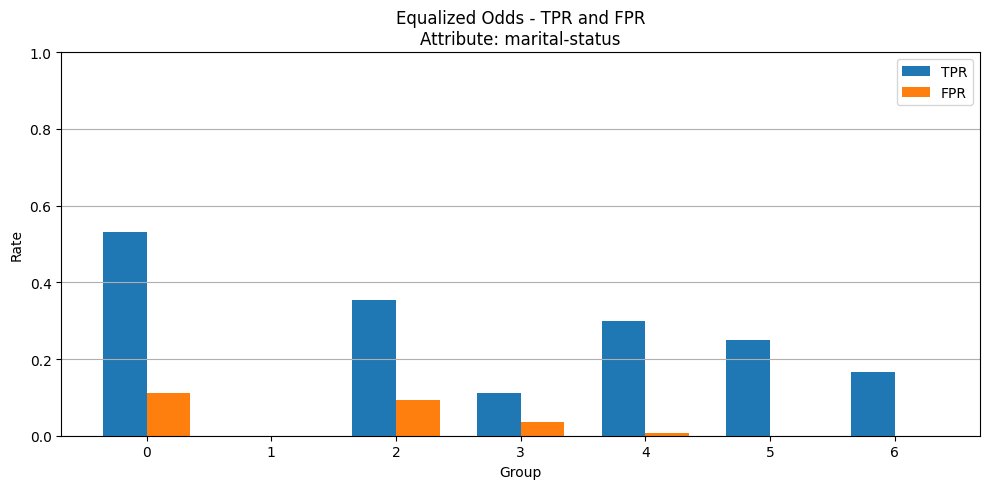

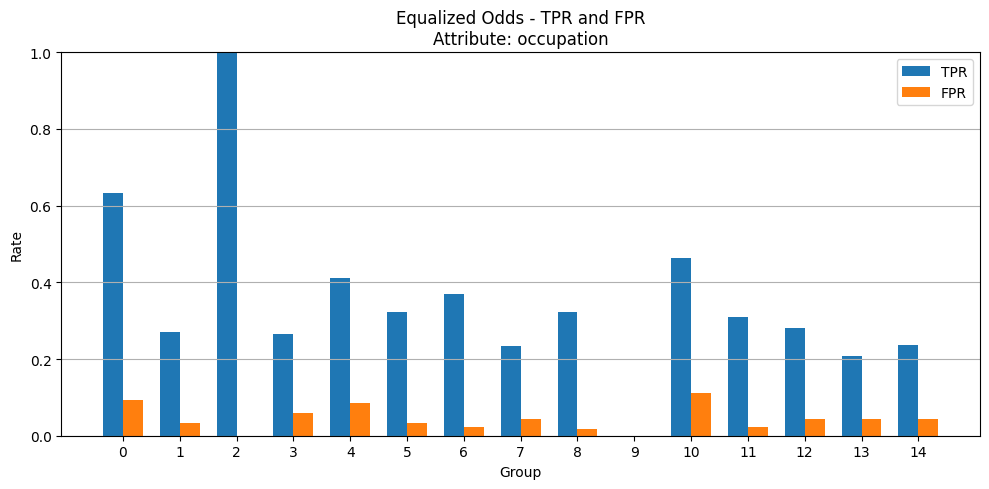

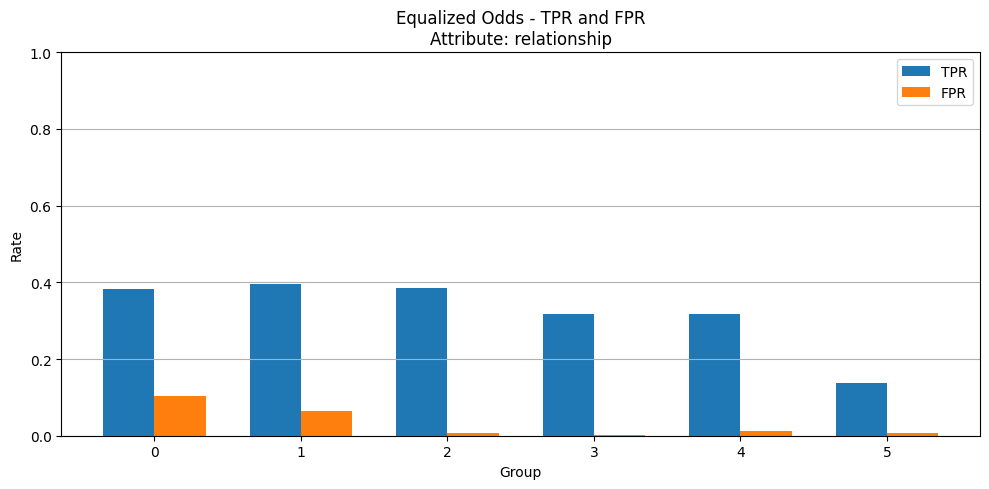

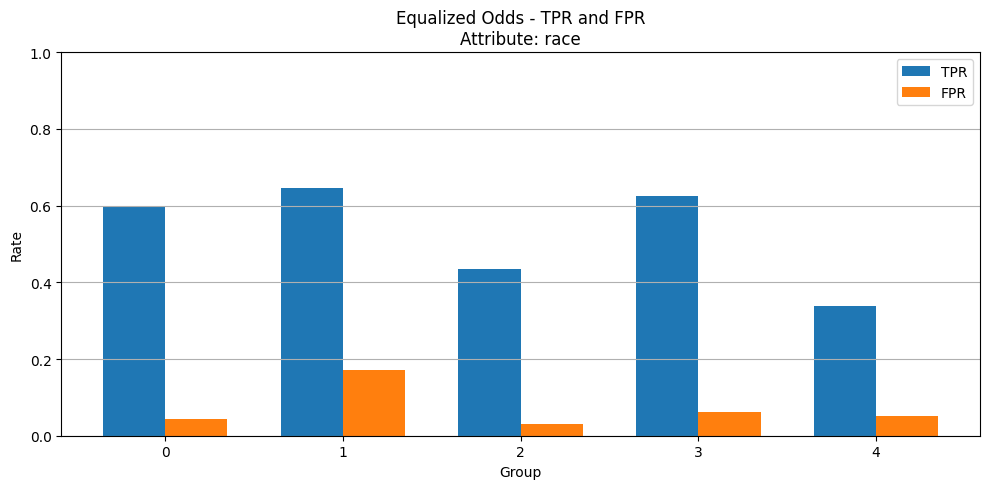

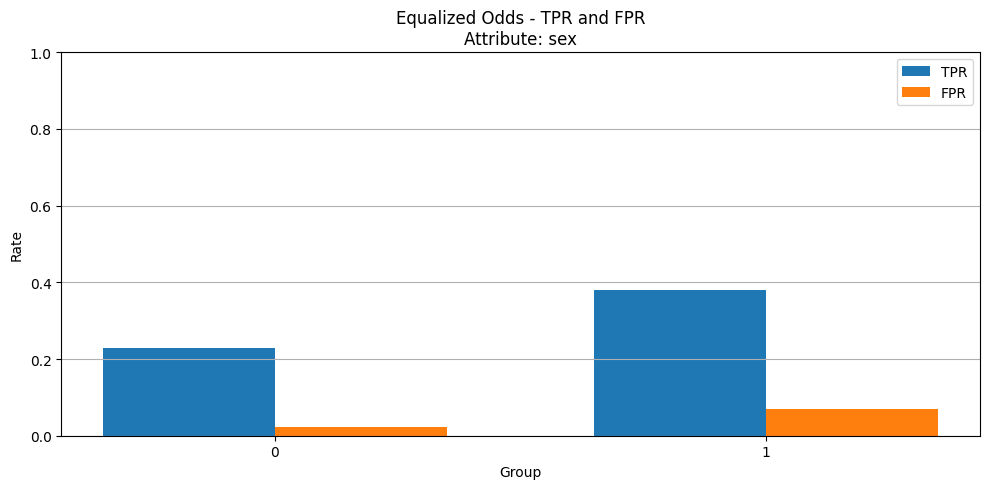

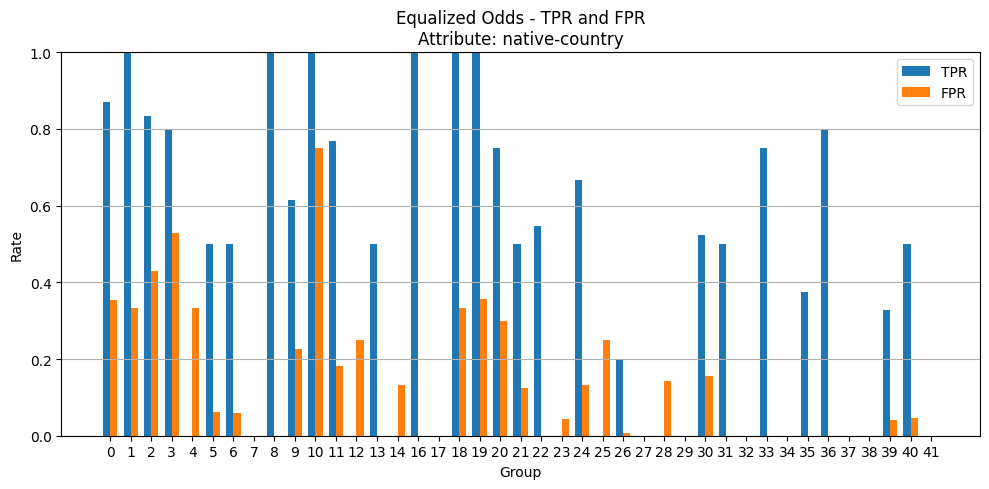

In [ ]:
for attr, metrics in eq_odd_results.items():
        groups = list(metrics.keys())
        tpr_values = [metrics[g]['TPR'] for g in groups]
        fpr_values = [metrics[g]['FPR'] for g in groups]

        x = np.arange(len(groups))
        width = 0.35

        plt.figure(figsize=(10,5))
        plt.bar(x - width/2, tpr_values, width, label='TPR')
        plt.bar(x + width/2, fpr_values, width, label='FPR')

        plt.title(f"Equalized Odds - TPR and FPR\nAttribute: {attr}")
        plt.xlabel("Group")
        plt.ylabel("Rate")
        plt.ylim(0, 1)
        plt.xticks(x, groups)
        plt.legend()
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()

Causal inference


In [ ]:
import dowhy
from dowhy import CausalModel



In [ ]:
#Make binaryt treatment 'married' from given marital status
data['married'] = data['marital-status'].apply(lambda x: 1 if x in [1,2] else 0)

treatment = 'married'
outcome = 'income'

#Outcome, treatment and original marital status are excluded
confounders = ['age', 'education-num', 'sex', 'race', 'hours-per-week']

print(f"Running  with treatment: {treatment} and outcome:  {outcome}")
print(f"Confounders: {confounders}")



Running  with treatment: married and outcome:  income
Confounders: ['age', 'education-num', 'sex', 'race', 'hours-per-week']


Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                                          
──────────(E[income|sex,education-num,age,hours-per-week,race])
d[married]                                                     
Estimand assumption 1, Unconfoundedness: If U→{married} and U→income then P(income|married,sex,education-num,age,hours-per-week,race,U) = P(income|married,sex,education-num,age,hours-per-week,race)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                                                          
──────────(E[income|sex,education-num,age,hours-per-week,race])
d[married]                                                     
Estimand assumption 1, Unconfoundedness: If U→{married} and U→income then P(income

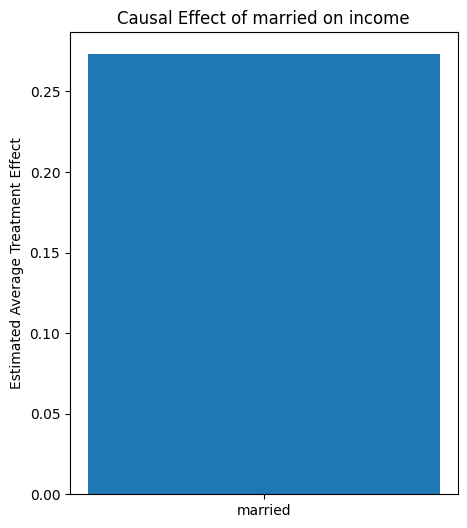

In [ ]:
model = CausalModel(
    data=data,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders
)

# Identify causal effect estimand
identified_estimand = model.identify_effect()
print("Identified estimand:")
print(identified_estimand)


#Estimate causal effect by matching propensity score
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_matching")
print(f"Causal estimate (ATE):{estimate.value:.4f} ")

# Refute estimate with placebo treatment refuter
refute_results = model.refute_estimate(identified_estimand, estimate,
                                      method_name="placebo_treatment_refuter")
print("Refutation results:")
print(refute_results)

# Plot estimated average tretment effect (ATE)
plt.figure(figsize=(5,6))
plt.bar([treatment], [estimate.value])
plt.ylabel("Estimated Average Treatment Effect")
plt.title(f"Causal Effect of {treatment} on {outcome}")
plt.show()